In [1]:
#!/usr/bin/env python

import os
import json
import joblib
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import textwrap
import re
import hashlib
import numpy as np
import pandas as pd
import statsmodels.api as sm

# CONFIG
model_dir = Path("./Ridge_OTU_Trained_Models/")
ukb_metadata_path = "variable_mapping/ukb_as_agp_metadata.csv"
ukb_index_col = "sample_name"

# outcome variable in UKB-like file
cognition_col = "fluid_intelligence_score"

# covariates (match your existing projection style)
cov_num = ["age_corrected"]                 # continuous
cov_cat = ["race", "country_of_birth"]      # categorical

out_dir = Path("./hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/")
out_dir.mkdir(parents=True, exist_ok=True)

# filter rows
# - We skip some high-missing lifestyle columns (and categorical covariates) when computing per-row missingness
EXCLUDE_METADATA_COLS = [
    "cat",
    "dog",
    "multivitamin",
    "other_supplement_frequency",
    "cosmetics_frequency",
    "fermented_plant_frequency",
    "homecooked_meals_frequency",
    "meat_eggs_frequency",
    "sugary_sweets_frequency",
    "vivid_dreams",
    "sugar_sweetened_drink_frequency",
    "artificial_sweeteners",
    "olive_oil",
    "prepared_meals_frequency",
    "ready_to_eat_meals_frequency",
]
skip_cols = list(EXCLUDE_METADATA_COLS) + list(cov_cat)   # ignore these when computing per-row missingness
max_missing_frac = 0.20 # keep rows with <=10% missing across cols_check
required_for_regression = [cognition_col] + cov_num

# HELPERS
def filter_rows_by_missingness(df, *, skip_cols=(), required_cols=(), max_missing_frac=0.10):
    skip_cols = list(skip_cols)
    required_cols = list(required_cols)

    missing_skip = [c for c in skip_cols if c not in df.columns]
    if missing_skip:
        print(f"[WARN] skip_cols not in dataframe (ignored): {missing_skip[:10]}{'...' if len(missing_skip)>10 else ''}")

    cols_check = [c for c in df.columns if c not in set(skip_cols)]
    if len(cols_check) == 0:
        raise ValueError("After applying skip_cols, cols_check is empty. Reduce skip_cols.")

    missing_frac = df[cols_check].isna().mean(axis=1)
    n_in = df.shape[0]
    mask = missing_frac <= max_missing_frac
    df_f = df.loc[mask].copy()

    required_present = [c for c in required_cols if c in df_f.columns]
    df_f = df_f.dropna(subset=required_present)

    n_out = df_f.shape[0]
    report = {
        "n_in": n_in,
        "n_out": n_out,
        "dropped": n_in - n_out,
        "cols_check_n": len(cols_check),
        "missing_frac_summary": missing_frac.describe().to_dict()
    }
    return df_f, report

def build_covariates(df, cov_num, cov_cat):
    parts = []
    if cov_num:
        parts.append(df[cov_num].apply(pd.to_numeric, errors="coerce"))
    if cov_cat:
        parts.append(pd.get_dummies(
            df[cov_cat].astype("string").fillna("MISSING"),
            prefix=cov_cat,
            drop_first=True,
            dtype=float
        ))
    cov_df = pd.concat(parts, axis=1) if parts else pd.DataFrame(index=df.index)
    return cov_df

def fit_ols_hc3(y, X):
    return sm.OLS(y, X).fit(cov_type="HC3")

# LOAD MODELS + TRAINING METADATA
models_path = model_dir / "ridge_otu_models.pkl"
meta_path   = model_dir / "ridge_training_metadata.json"

ridge_models = joblib.load(models_path)
with open(meta_path, "r") as f:
    train_meta = json.load(f)

train_cols = train_meta["train_cols"]
saved_otus = train_meta["saved_otus"]

print(f"Loaded ridge OTU models: {len(ridge_models)}")
print(f"Training expects X columns: {len(train_cols)}")
print(f"OTUs to predict: {len(saved_otus)}")

Loaded ridge OTU models: 32
Training expects X columns: 29
OTUs to predict: 32


In [2]:
train_cols

['alcohol_consumption',
 'appendix_removed',
 'lactose',
 'alcohol_frequency',
 'exercise_frequency',
 'flossing_frequency',
 'frozen_dessert_frequency',
 'fruit_frequency',
 'high_fat_red_meat_frequency',
 'milk_cheese_frequency',
 'milk_substitute_frequency',
 'one_liter_of_water_a_day_frequency',
 'poultry_frequency',
 'probiotic_frequency',
 'red_meat_frequency',
 'salted_snacks_frequency',
 'seafood_frequency',
 'smoking_frequency',
 'teethbrushing_frequency',
 'vegetable_frequency',
 'vitamin_b_supplement_frequency',
 'vitamin_d_supplement_frequency',
 'whole_eggs',
 'whole_grain_frequency',
 'bowel_movement_frequency',
 'sleep_duration',
 'sex',
 'bmi',
 'weight_kg']

In [3]:
# filter UKB data
ukb_df_raw = pd.read_csv(ukb_metadata_path, index_col=ukb_index_col)
print(f"Loaded UKB-like metadata: {ukb_df_raw.shape[0]} rows, {ukb_df_raw.shape[1]} cols")

# PRE-FILTER UKB QUICK DISTRIBUTION REPORT
out_pdf_path = out_dir / "UKB_pre_filter_distributions.pdf"

# Hard-coded: keep only these as categorical
categorical_keep = {"country_of_birth", "country", "race"}

# Plot settings
top_k_categories = 25
numeric_bins = 30
treat_numeric_as_categorical_if_unique_leq = 15

def force_numeric_everything_else(df: pd.DataFrame, categorical_keep: set) -> pd.DataFrame:
    df = df.copy()
    for c in df.columns:
        if c in categorical_keep:
            df[c] = df[c].astype("string")
        else:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def plot_categorical_with_missing_right(ax, s_raw: pd.Series, title: str, top_k: int = 25):
    """
    Barplot of proportions for categorical-like series.
    Ensures 'MISSING' is always the last bar (rightmost).
    Collapses tail into 'Other' (excluding MISSING).
    """
    s = s_raw.astype("string").fillna("MISSING")

    vc = s.value_counts(dropna=False)
    n = int(vc.sum()) if vc.sum() > 0 else 0

    missing_ct = int(vc.get("MISSING", 0))
    vc_no_missing = vc.drop(index=["MISSING"], errors="ignore")

    # Top-K (non-missing)
    if vc_no_missing.shape[0] > top_k:
        top = vc_no_missing.head(top_k)
        other_ct = int(vc_no_missing.iloc[top_k:].sum())
        vc_plot = top.copy()
        if other_ct > 0:
            vc_plot.loc["Other"] = other_ct
    else:
        vc_plot = vc_no_missing.copy()

    # Append MISSING as rightmost
    if missing_ct > 0:
        vc_plot.loc["MISSING"] = missing_ct

    probs = (vc_plot / max(1, n)).astype(float)

    ax.bar(probs.index.astype(str), probs.values)
    ax.set_title(f"{title} (n={n}, missing={missing_ct}={missing_ct/max(1,n):.1%})")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=90)

def plot_numeric_discrete_with_missing_right(ax, s_num: pd.Series, title: str, top_k: int = 25):
    """
    Discrete numeric values plotted as categorical bars (proportions).
    Ensures 'MISSING' rightmost.
    """
    n_total = int(s_num.shape[0])
    n_missing = int(s_num.isna().sum())
    s_non = s_num.dropna()

    if s_non.empty:
        # Only missing
        ax.bar(["MISSING"], [1.0])
        ax.set_title(f"{title} (n={n_total}, missing={n_missing}={n_missing/max(1,n_total):.1%})")
        ax.set_ylabel("Proportion")
        return

    vc = s_non.value_counts()
    # if too many unique, keep top_k by freq, rest -> Other
    if vc.shape[0] > top_k:
        top = vc.head(top_k)
        other_ct = int(vc.iloc[top_k:].sum())
        vc_plot = top.copy()
        vc_plot.loc["Other"] = other_ct
    else:
        vc_plot = vc.copy()

    # sort numeric keys (keep Other last-ish, and Missing last)
    def fmt_num(x):
        try:
            fx = float(x)
            if np.isfinite(fx) and fx.is_integer():
                return str(int(fx))
            return f"{fx:g}"
        except Exception:
            return str(x)

    idx = list(vc_plot.index)

    # separate numeric vs Other
    numeric_keys = [k for k in idx if k != "Other"]
    numeric_keys_sorted = sorted(numeric_keys, key=lambda k: float(k))
    ordered = numeric_keys_sorted + (["Other"] if "Other" in idx else []) + (["MISSING"] if n_missing > 0 else [])

    # build counts aligned
    counts = []
    for k in ordered:
        if k == "MISSING":
            counts.append(n_missing)
        elif k == "Other":
            counts.append(int(vc_plot.loc["Other"]))
        else:
            counts.append(int(vc_plot.loc[k]))

    probs = np.array(counts, dtype=float) / max(1, n_total)

    labels = [fmt_num(k) if k not in {"Other","MISSING"} else k for k in ordered]

    ax.bar(labels, probs)
    ax.set_title(f"{title} (n={n_total}, missing={n_missing}={n_missing/max(1,n_total):.1%})")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=90)

# --- Use a numeric-coerced copy ONLY for visualization (pre-filter) ---
ukb_viz = force_numeric_everything_else(ukb_df_raw, categorical_keep)

with PdfPages(out_pdf_path) as pdf:
    for col in ukb_viz.columns:
        s = ukb_viz[col]

        fig, ax = plt.subplots(1, 1, figsize=(10, 4), constrained_layout=True)

        if col in categorical_keep:
            plot_categorical_with_missing_right(ax, s, title=f"UKB pre-filter: {col}", top_k=top_k_categories)

        else:
            # numeric column (after coercion)
            nunq = int(s.dropna().nunique())

            if nunq <= treat_numeric_as_categorical_if_unique_leq:
                plot_numeric_discrete_with_missing_right(ax, s, title=f"UKB pre-filter: {col}", top_k=top_k_categories)
            else:
                # continuous numeric histogram (missing shown in title)
                x = s.dropna().values.astype(float)
                n_total = int(len(s))
                n_missing = int(s.isna().sum())
                if len(x) == 0:
                    ax.text(0.5, 0.5, "No non-missing numeric values", ha="center", va="center")
                    ax.set_axis_off()
                else:
                    bins = np.histogram_bin_edges(x, bins=numeric_bins)
                    ax.hist(x, bins=bins)
                    ax.set_ylabel("Count")
                ax.set_title(f"UKB pre-filter: {col} (n={n_total}, missing={n_missing}={n_missing/max(1,n_total):.1%})")

        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved pre-filter UKB distribution PDF to:\n  {out_pdf_path}")

Loaded UKB-like metadata: 502244 rows, 48 cols
Saved pre-filter UKB distribution PDF to:
  hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/UKB_pre_filter_distributions.pdf


In [4]:
# Reduce UKB dataframe to ONLY the columns needed downstream
# (prevents row-missingness filtering from being dominated by unrelated/high-missing columns)
needed_cols = sorted(set(train_cols) | set([cognition_col] + cov_num + cov_cat))
present_needed = [c for c in needed_cols if c in ukb_df_raw.columns]
missing_needed = [c for c in needed_cols if c not in ukb_df_raw.columns]
if missing_needed:
    print(f"[WARN] UKB is missing {len(missing_needed)} / {len(needed_cols)} needed cols (they will be treated as all-NA at prediction time).")
    print("First 25 missing needed cols:", missing_needed[:25])

ukb_df = ukb_df_raw[present_needed].copy()

# Optional row filtering (keeps analysis sample sane)
ukb_df, miss_report = filter_rows_by_missingness(
    ukb_df,
    skip_cols=skip_cols,
    required_cols=required_for_regression,
    max_missing_frac=max_missing_frac
)
print("\n[ROW FILTER REPORT]")
print(f"Input rows:   {miss_report['n_in']}")
print(f"Output rows:  {miss_report['n_out']}")
print(f"Dropped rows: {miss_report['dropped']}")
print(f"Cols counted toward missingness: {miss_report['cols_check_n']}")

[WARN] skip_cols not in dataframe (ignored): ['cat', 'dog', 'multivitamin', 'other_supplement_frequency', 'cosmetics_frequency', 'fermented_plant_frequency', 'homecooked_meals_frequency', 'meat_eggs_frequency', 'sugary_sweets_frequency', 'vivid_dreams']...

[ROW FILTER REPORT]
Input rows:   502244
Output rows:  85987
Dropped rows: 416257
Cols counted toward missingness: 31


In [5]:
# plot the distribution of the data of UKB and AGP
agp_metadata_path = "./Data/Cleaned_data/processed_metadata.csv"
agp_index_col = "sample_name"

out_dir.mkdir(parents=True, exist_ok=True)

out_pdf_path = out_dir / "AGP_vs_UKB_distributions.pdf"
out_summary_csv = out_dir / "AGP_vs_UKB_drift_summary.csv"

cols_to_compare = None  # or e.g. train_cols if you want only predictors used by ridge

top_k_categories = 20
numeric_bins = 30
treat_numeric_as_categorical_if_unique_leq = 15

# Only these remain categorical
categorical_keep = {"country_of_birth", "country", "race"}

# HELPERS (minimal)
def _as_categorical(series: pd.Series) -> pd.Series:
    return series.astype("string").fillna("MISSING")

def _tv_distance(p: pd.Series, q: pd.Series) -> float:
    return float(0.5 * np.abs(p.values - q.values).sum())

def _std_mean_diff(x: np.ndarray, y: np.ndarray) -> float:
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    mx, my = np.mean(x), np.mean(y)
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    sp = np.sqrt((sx**2 + sy**2) / 2.0)
    return float((my - mx) / sp) if sp > 0 else np.nan

def _plot_numeric(ax, vals, bins, title):
    ax.hist(vals, bins=bins)
    ax.set_title(title)
    ax.set_ylabel("Count")

def _plot_categorical(ax, probs: pd.Series, title):
    ax.bar(probs.index.astype(str), probs.values)
    ax.set_title(title)
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=90)

def force_numeric_everything_else(df: pd.DataFrame, categorical_keep: set) -> pd.DataFrame:
    df = df.copy()
    for c in df.columns:
        if c in categorical_keep:
            df[c] = df[c].astype("string")
        else:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def clean_num_tick(x):
    # 1.0 -> "1", 1.25 -> "1.25"
    try:
        fx = float(x)
        if np.isfinite(fx) and fx.is_integer():
            return str(int(fx))
        return f"{fx:g}"
    except Exception:
        return str(x)

# LOAD AGP + use FILTERED ukb_df (already in memory)
agp_df = pd.read_csv(agp_metadata_path, index_col=agp_index_col)

print(f"AGP metadata loaded: {agp_df.shape}")
print(f"UKB (FILTERED) loaded: {ukb_df.shape}  <-- using your filtered dataframe")

# Force numeric typing (prevents '1' vs '1.0')
agp_df = force_numeric_everything_else(agp_df, categorical_keep)
ukb_df_num = force_numeric_everything_else(ukb_df, categorical_keep)  # don't overwrite if you want

# Shared columns (post-typing)
shared_cols = sorted(set(agp_df.columns).intersection(set(ukb_df_num.columns)))
print(f"Shared columns between AGP and filtered UKB: {len(shared_cols)}")

if cols_to_compare is not None:
    shared_cols = [c for c in shared_cols if c in set(cols_to_compare)]
    print(f"After cols_to_compare restriction: {len(shared_cols)}")

# ITERATE + SAVE MULTIPAGE PDF
drift_rows = []

with PdfPages(out_pdf_path) as pdf:
    for col in shared_cols:
        s_agp = agp_df[col]
        s_ukb = ukb_df_num[col]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

        if col in categorical_keep:
            c_agp = _as_categorical(s_agp)
            c_ukb = _as_categorical(s_ukb)

            vc_agp = c_agp.value_counts(normalize=True, dropna=False)
            vc_ukb = c_ukb.value_counts(normalize=True, dropna=False)

            top_union = list(pd.Index(vc_agp.head(top_k_categories).index).union(vc_ukb.head(top_k_categories).index))
            p = vc_agp.reindex(top_union, fill_value=0.0)
            q = vc_ukb.reindex(top_union, fill_value=0.0)

            avg = (p + q) / 2.0
            keep = avg.sort_values(ascending=False).head(top_k_categories).index
            p2 = p.reindex(keep).copy()
            q2 = q.reindex(keep).copy()

            p2.loc["Other"] = float(1.0 - p2.sum())
            q2.loc["Other"] = float(1.0 - q2.sum())

            _plot_categorical(axes[0], p2, f"AGP: {col} (n={c_agp.notna().sum()})")
            _plot_categorical(axes[1], q2, f"UKB: {col} (n={c_ukb.notna().sum()})")

            tv = _tv_distance(p2 / p2.sum(), q2 / q2.sum())

            drift_rows.append({
                "column": col,
                "type": "categorical",
                "agp_n_nonmissing": int(s_agp.notna().sum()),
                "ukb_n_nonmissing": int(s_ukb.notna().sum()),
                "tv_distance": tv,
                "std_mean_diff": np.nan
            })

        else:
            nunq = int(max(s_agp.dropna().nunique(), s_ukb.dropna().nunique()))

            if nunq <= treat_numeric_as_categorical_if_unique_leq:
                vc_agp = s_agp.dropna().value_counts(normalize=True)
                vc_ukb = s_ukb.dropna().value_counts(normalize=True)

                cats = sorted(set(vc_agp.index).union(set(vc_ukb.index)))
                p2 = vc_agp.reindex(cats, fill_value=0.0)
                q2 = vc_ukb.reindex(cats, fill_value=0.0)

                if len(cats) > top_k_categories:
                    avg = (p2 + q2) / 2.0
                    keep = avg.sort_values(ascending=False).head(top_k_categories).index
                    p2 = p2.reindex(keep).copy()
                    q2 = q2.reindex(keep).copy()
                    p2.loc["Other"] = float(1.0 - p2.sum())
                    q2.loc["Other"] = float(1.0 - q2.sum())

                # clean tick labels
                labels = [clean_num_tick(x) if x != "Other" else "Other" for x in p2.index]
                p2.index = labels
                q2.index = labels

                _plot_categorical(axes[0], p2, f"AGP: {col} (n={int(s_agp.notna().sum())})")
                _plot_categorical(axes[1], q2, f"UKB: {col} (n={int(s_ukb.notna().sum())})")

                tv = _tv_distance(p2 / p2.sum(), q2 / q2.sum()) if (p2.sum() > 0 and q2.sum() > 0) else np.nan

                drift_rows.append({
                    "column": col,
                    "type": "numeric_discrete",
                    "agp_n_nonmissing": int(s_agp.notna().sum()),
                    "ukb_n_nonmissing": int(s_ukb.notna().sum()),
                    "tv_distance": tv,
                    "std_mean_diff": np.nan
                })

            else:
                x = s_agp.dropna().values.astype(float)
                y = s_ukb.dropna().values.astype(float)

                if len(x) == 0 or len(y) == 0:
                    axes[0].text(0.5, 0.5, f"No numeric data (AGP)\n{col}", ha="center", va="center")
                    axes[1].text(0.5, 0.5, f"No numeric data (UKB)\n{col}", ha="center", va="center")
                    axes[0].set_axis_off()
                    axes[1].set_axis_off()
                    smd = np.nan
                else:
                    combined = np.concatenate([x, y])
                    bins = np.histogram_bin_edges(combined, bins=numeric_bins)

                    _plot_numeric(axes[0], x, bins, f"AGP: {col} (n={len(x)})")
                    _plot_numeric(axes[1], y, bins, f"UKB: {col} (n={len(y)})")

                    lo, hi = float(np.nanmin(combined)), float(np.nanmax(combined))
                    axes[0].set_xlim(lo, hi)
                    axes[1].set_xlim(lo, hi)

                    smd = _std_mean_diff(x, y)

                drift_rows.append({
                    "column": col,
                    "type": "numeric_continuous",
                    "agp_n_nonmissing": int(len(x)),
                    "ukb_n_nonmissing": int(len(y)),
                    "tv_distance": np.nan,
                    "std_mean_diff": smd
                })

        fig.suptitle(f"Distribution check: {col}", y=1.02, fontsize=12)
        pdf.savefig(fig)
        plt.close(fig)

# Save drift summary
drift_df = pd.DataFrame(drift_rows)
drift_df["shift_score"] = np.where(
    drift_df["tv_distance"].notna(),
    drift_df["tv_distance"].astype(float),
    np.abs(drift_df["std_mean_diff"].astype(float))
)
drift_df = drift_df.sort_values("shift_score", ascending=False)
drift_df.to_csv(out_summary_csv, index=False)

print(f"\nSaved PDF to: {out_pdf_path}")
print(f"Saved drift CSV to: {out_summary_csv}")
print("\nTop 20 most-shifted columns:")
print(drift_df[["column","type","shift_score","tv_distance","std_mean_diff","agp_n_nonmissing","ukb_n_nonmissing"]].head(20).to_string(index=False))

AGP metadata loaded: (9559, 48)
UKB (FILTERED) loaded: (85987, 33)  <-- using your filtered dataframe
Shared columns between AGP and filtered UKB: 32

Saved PDF to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/AGP_vs_UKB_distributions.pdf
Saved drift CSV to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/AGP_vs_UKB_drift_summary.csv

Top 20 most-shifted columns:
                            column               type  shift_score  tv_distance  std_mean_diff  agp_n_nonmissing  ukb_n_nonmissing
                    sleep_duration   numeric_discrete     0.987342     0.987342            NaN              9559             85796
                     age_corrected numeric_continuous     0.751503          NaN       0.751503              9215             85987
                  country_of_birth        categorical     0.748672     0.748672            NaN              9559             85987
    vitamin_b_supplement_frequency   numeric_discrete     0.726542     0.7265

In [6]:
# BUILD UKB X (exact training cols)
X_ukb = ukb_df.reindex(columns=train_cols)
X_ukb = X_ukb.apply(pd.to_numeric, errors="coerce")

missing_cols = [c for c in train_cols if c not in ukb_df.columns]
print(f"UKB is missing {len(missing_cols)} / {len(train_cols)} training columns.")
if missing_cols:
    print("First 25 missing cols:", missing_cols[:25])

missing_rate = float(np.mean(pd.isna(X_ukb.values)))
print(f"Overall missing rate in X_ukb (after numeric coercion): {missing_rate*100:.2f}%")

# PREDICT OTU PROXIES IN UKB
otu_hat = pd.DataFrame(index=ukb_df.index)

for otu in saved_otus:
    if otu not in ridge_models:
        print(f"[WARN] OTU model missing in ridge_models.pkl: {otu} (skipping)")
        continue
    otu_hat[f"{otu}__hat"] = ridge_models[otu].predict(X_ukb)

otu_hat_path = out_dir / "ukb_predicted_otus.csv"
otu_hat.to_csv(otu_hat_path)
print(f"Saved predicted OTU proxies to: {otu_hat_path}")

# REGRESSION: fluid intelligence ~ OTU_hat + covariates (UNIVARIATE per OTU)
if cognition_col not in ukb_df.columns:
    raise ValueError(f"Outcome column not found: {cognition_col}")

y = pd.to_numeric(ukb_df[cognition_col], errors="coerce")
cov_df = build_covariates(ukb_df, cov_num=cov_num, cov_cat=cov_cat)

# Lock sample using outcome + covariates (predictions have no NA because pipeline imputes)
base = pd.concat([y.rename("y"), cov_df], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
print(f"\nRows available for regression after locking y+covariates: {base.shape[0]}")

y_clean = base["y"].astype(float)
cov_clean = base.drop(columns=["y"]).astype(float)
cov_clean = sm.add_constant(cov_clean, has_constant="add")

reg_rows = []

for col in otu_hat.columns:
    # align with locked sample
    x1 = otu_hat.loc[base.index, col].astype(float)
    Xmat = pd.concat([cov_clean, x1.rename(col)], axis=1)

    fit = fit_ols_hc3(y_clean, Xmat)

    reg_rows.append({
        "otu_hat": col,
        "beta": float(fit.params[col]),
        "se_hc3": float(fit.bse[col]),
        "t_hc3": float(fit.tvalues[col]),
        "p_value": float(fit.pvalues[col]),
        "n": int(fit.nobs),
        "r2": float(fit.rsquared),
        "adj_r2": float(fit.rsquared_adj),
    })

reg_df = pd.DataFrame(reg_rows).sort_values("p_value")

# BH-FDR across OTUs
if reg_df.shape[0] > 0:
    rej, qvals, _, _ = multipletests(reg_df["p_value"].values, alpha=0.05, method="fdr_bh")
    reg_df["q_value_BH"] = qvals
    reg_df["reject_FDR_0p05"] = rej

reg_path = out_dir / "ukb_fluid_intelligence_on_otu_hat_univariate.csv"
reg_df.to_csv(reg_path, index=False)
print(f"Saved univariate regression results to: {reg_path}")

print("\nTop 20 OTU proxies by p-value:")
print(reg_df.head(20).to_string(index=False))

# OPTIONAL: one JOINT model with ALL OTU_hats + covariates
# (can be unstable if many OTUs; use only if dimensionality is reasonable)
do_joint = False
if do_joint:
    X_joint = pd.concat([cov_df, otu_hat], axis=1)
    X_joint = sm.add_constant(X_joint, has_constant="add").replace([np.inf, -np.inf], np.nan)
    joint_data = pd.concat([y.rename("y"), X_joint], axis=1).dropna()
    yj = joint_data["y"].astype(float)
    Xj = joint_data.drop(columns=["y"]).astype(float)

    fit_joint = fit_ols_hc3(yj, Xj)
    joint_path = out_dir / "ukb_joint_model_summary.txt"
    with open(joint_path, "w") as f:
        f.write(fit_joint.summary().as_text())
    print(f"Saved JOINT model summary to: {joint_path}")

UKB is missing 0 / 29 training columns.
Overall missing rate in X_ukb (after numeric coercion): 14.60%
Saved predicted OTU proxies to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/ukb_predicted_otus.csv

Rows available for regression after locking y+covariates: 85987
Saved univariate regression results to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/ukb_fluid_intelligence_on_otu_hat_univariate.csv

Top 20 OTU proxies by p-value:
                                                         otu_hat      beta   se_hc3      t_hc3       p_value     n       r2   adj_r2    q_value_BH  reject_FDR_0p05
                   Ruminococcaceae_Intestinimonas__1177c4dc__hat  0.880700 0.025181  34.974344 5.524539e-268 85987 0.061225 0.061137 1.767853e-266             True
                Lachnospiraceae_Lachnoclostridium__1d7bd554__hat -0.809515 0.025628 -31.586984 5.572450e-219 85987 0.058877 0.058790 8.915919e-218             True
       Erysipelotrichaceae_Erysipelato

In [7]:
# ============================================================
# BLOCK 9 (REFINED)
# Export OLS / HC3 tables for OTU_hat models
# Rank by:
#   1) p-value
#   2) increase in R² beyond covariates (delta R²)
#
# IMPORTANT:
# - delta R² is computed across ALL OTUs, not only the top p-value OTUs
# - baseline model is fit ONCE and reused
#
# Requires:
#   reg_df, otu_hat, base, y_clean, cov_clean, out_dir
# ============================================================

top_n = 20
use_hc3 = True

ols_dir = out_dir / "top20_otu_ols_tables"
ols_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# sanity checks
# -----------------------------
required_objs = ["reg_df", "otu_hat", "base", "y_clean", "cov_clean", "out_dir"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"Required object '{obj_name}' not found in memory.")

if reg_df.shape[0] == 0:
    raise ValueError("reg_df is empty; no regression results available.")

# Ensure covariates include constant exactly once
cov_clean = sm.add_constant(cov_clean, has_constant="add")

# -----------------------------
# baseline model fit ONCE
# -----------------------------
fit_base_global = sm.OLS(y_clean, cov_clean).fit()
baseline_r2_global = float(fit_base_global.rsquared)
baseline_adj_r2_global = float(fit_base_global.rsquared_adj)

# -----------------------------
# build ALL-OTU summary table
# reg_df already contains full-model R² for each OTU model
# -----------------------------
summary_all = reg_df.copy()

summary_all["baseline_r2"] = baseline_r2_global
summary_all["baseline_adj_r2"] = baseline_adj_r2_global
summary_all["delta_r2"] = summary_all["r2"] - baseline_r2_global
summary_all["delta_adj_r2"] = summary_all["adj_r2"] - baseline_adj_r2_global

den = 1.0 - baseline_r2_global
summary_all["partial_r2"] = np.where(den > 0, summary_all["delta_r2"] / den, np.nan)

summary_all["rank_by_p"] = summary_all["p_value"].rank(method="first", ascending=True).astype(int)
summary_all["rank_by_delta_r2"] = summary_all["delta_r2"].rank(method="first", ascending=False).astype(int)

summary_all = summary_all.sort_values("rank_by_p").reset_index(drop=True)

summary_all_path = ols_dir / "otu_model_summary_ALL_with_deltaR2.csv"
summary_all.to_csv(summary_all_path, index=False)

# -----------------------------
# select OTUs to export
# union of:
#   top N by p-value
#   top N by delta R²
# -----------------------------
top_by_p = summary_all.nsmallest(top_n, "p_value")["otu_hat"].tolist()
top_by_delta = summary_all.nlargest(top_n, "delta_r2")["otu_hat"].tolist()
selected_otus = list(pd.Index(top_by_p).union(top_by_delta))

selected_path = ols_dir / "selected_otus_union_top_by_p_and_deltaR2.csv"
pd.DataFrame({"otu_hat": selected_otus}).to_csv(selected_path, index=False)

print(f"Saved ALL-OTU summary to: {summary_all_path}")
print(f"Saved selected OTU union list to: {selected_path}")
print(f"Baseline R² (covariates only): {baseline_r2_global:.6f}")

# helper for safe filenames
def slugify(name: str, maxlen: int = 80) -> str:
    s = re.sub(r"[^A-Za-z0-9._-]+", "_", str(name))
    if len(s) <= maxlen:
        return s
    h = hashlib.md5(str(name).encode("utf-8")).hexdigest()[:10]
    return s[: maxlen - 11] + "_" + h

all_coef_tables = []
otu_summary_rows = []

for export_rank, otu_col in enumerate(selected_otus, start=1):

    if otu_col not in otu_hat.columns:
        print(f"[WARN] {otu_col} not found in otu_hat columns, skipping.")
        continue

    # predicted OTU on locked sample
    x_otu = otu_hat.loc[base.index, otu_col].astype(float).rename(otu_col)

    # normally no missingness here, but keep a guard
    model_df = pd.concat(
        [y_clean.rename("fluid_intelligence_score"), cov_clean, x_otu],
        axis=1
    ).replace([np.inf, -np.inf], np.nan).dropna()

    if model_df.shape[0] < 10:
        print(f"[WARN] Too few rows for {otu_col}, skipping.")
        continue

    y_model = model_df["fluid_intelligence_score"]

    # baseline model: covariates only
    X_base = model_df[cov_clean.columns]
    fit_base = sm.OLS(y_model, X_base).fit()

    # full model: covariates + OTU_hat
    X_full = model_df.drop(columns=["fluid_intelligence_score"])
    X_full = sm.add_constant(X_full, has_constant="add")
    fit_full = sm.OLS(y_model, X_full).fit()

    # robust coefficient table if requested
    if use_hc3:
        fit_used = fit_full.get_robustcov_results(cov_type="HC3")
        coef_table = pd.DataFrame({
            "term": X_full.columns,
            "coef": fit_used.params,
            "std_err": fit_used.bse,
            "t": fit_used.tvalues,
            "p_value": fit_used.pvalues,
            "ci_lower": fit_used.conf_int()[:, 0],
            "ci_upper": fit_used.conf_int()[:, 1],
        })
        cov_type_label = "HC3"
    else:
        coef_table = pd.DataFrame({
            "term": fit_full.params.index,
            "coef": fit_full.params.values,
            "std_err": fit_full.bse.values,
            "t": fit_full.tvalues.values,
            "p_value": fit_full.pvalues.values,
            "ci_lower": fit_full.conf_int().iloc[:, 0].values,
            "ci_upper": fit_full.conf_int().iloc[:, 1].values,
        })
        cov_type_label = "OLS"

    # model comparison metrics
    baseline_r2 = float(fit_base.rsquared)
    full_r2 = float(fit_full.rsquared)
    delta_r2 = full_r2 - baseline_r2

    baseline_adj_r2 = float(fit_base.rsquared_adj)
    full_adj_r2 = float(fit_full.rsquared_adj)
    delta_adj_r2 = full_adj_r2 - baseline_adj_r2

    if (1 - baseline_r2) > 0:
        partial_r2 = delta_r2 / (1 - baseline_r2)
    else:
        partial_r2 = np.nan

    f_stat, f_pvalue, f_df_diff = fit_full.compare_f_test(fit_base)

    # add metadata
    coef_table["otu_hat"] = otu_col
    coef_table["export_rank_union"] = export_rank
    coef_table["n"] = int(fit_full.nobs)
    coef_table["baseline_r2"] = baseline_r2
    coef_table["full_r2"] = full_r2
    coef_table["delta_r2"] = delta_r2
    coef_table["baseline_adj_r2"] = baseline_adj_r2
    coef_table["full_adj_r2"] = full_adj_r2
    coef_table["delta_adj_r2"] = delta_adj_r2
    coef_table["partial_r2"] = partial_r2
    coef_table["nested_f_stat"] = f_stat
    coef_table["nested_f_pvalue"] = f_pvalue
    coef_table["df_diff"] = f_df_diff
    coef_table["covariance_type"] = cov_type_label

    safe_name = slugify(otu_col)

    coef_csv_path = ols_dir / f"{export_rank:02d}_{safe_name}_coef_table.csv"
    coef_table.to_csv(coef_csv_path, index=False)

    txt_path = ols_dir / f"{export_rank:02d}_{safe_name}_model_summary.txt"
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(f"Export rank (union): {export_rank}\n")
        f.write(f"OTU_hat: {otu_col}\n")
        f.write(f"Covariance type: {cov_type_label}\n\n")

        f.write("===== BASELINE MODEL: fluid intelligence ~ covariates =====\n")
        f.write(fit_base.summary().as_text())

        f.write("\n\n===== FULL MODEL: fluid intelligence ~ covariates + OTU_hat =====\n")
        f.write(fit_full.summary().as_text())

        f.write("\n\n===== MODEL COMPARISON =====\n")
        f.write(f"baseline_r2      = {baseline_r2:.6f}\n")
        f.write(f"full_r2          = {full_r2:.6f}\n")
        f.write(f"delta_r2         = {delta_r2:.6f}\n")
        f.write(f"baseline_adj_r2  = {baseline_adj_r2:.6f}\n")
        f.write(f"full_adj_r2      = {full_adj_r2:.6f}\n")
        f.write(f"delta_adj_r2     = {delta_adj_r2:.6f}\n")
        f.write(f"partial_r2       = {partial_r2:.6f}\n")
        f.write(f"nested_F         = {f_stat:.6f}\n")
        f.write(f"nested_F_pvalue  = {f_pvalue:.6e}\n")
        f.write(f"df_diff          = {f_df_diff}\n")

        if use_hc3:
            f.write("\n\n===== HC3 ROBUST COEFFICIENT TABLE =====\n")
            f.write(coef_table.to_string(index=False))

    all_coef_tables.append(coef_table)

    otu_row = coef_table.loc[coef_table["term"] == otu_col].copy()
    if otu_row.shape[0] > 0:
        otu_summary_rows.append(otu_row)

# combined exports
if len(all_coef_tables) == 0:
    raise ValueError("No OLS tables were created.")

all_coef_df = pd.concat(all_coef_tables, axis=0, ignore_index=True)
all_coef_path = ols_dir / "ALL_selected_models_all_coefficients.csv"
all_coef_df.to_csv(all_coef_path, index=False)

if len(otu_summary_rows) == 0:
    raise ValueError("No OTU-term rows found in coefficient tables.")

otu_summary_df = pd.concat(otu_summary_rows, axis=0, ignore_index=True)

summary_cols = [
    "export_rank_union",
    "otu_hat",
    "coef",
    "std_err",
    "t",
    "p_value",
    "ci_lower",
    "ci_upper",
    "n",
    "baseline_r2",
    "full_r2",
    "delta_r2",
    "baseline_adj_r2",
    "full_adj_r2",
    "delta_adj_r2",
    "partial_r2",
    "nested_f_stat",
    "nested_f_pvalue",
    "df_diff",
    "covariance_type",
]
otu_summary_df = otu_summary_df[summary_cols].copy()

summary_by_p = otu_summary_df.sort_values("p_value", ascending=True).reset_index(drop=True)
summary_by_p.insert(0, "rank_by_p", np.arange(1, len(summary_by_p) + 1))
summary_by_p_path = ols_dir / "otu_term_summary_ranked_by_pvalue.csv"
summary_by_p.to_csv(summary_by_p_path, index=False)

summary_by_delta_r2 = otu_summary_df.sort_values("delta_r2", ascending=False).reset_index(drop=True)
summary_by_delta_r2.insert(0, "rank_by_delta_r2", np.arange(1, len(summary_by_delta_r2) + 1))
summary_by_delta_r2_path = ols_dir / "otu_term_summary_ranked_by_delta_r2.csv"
summary_by_delta_r2.to_csv(summary_by_delta_r2_path, index=False)

print(f"Saved combined coefficient table to: {all_coef_path}")
print(f"Saved OTU summary ranked by p-value to: {summary_by_p_path}")
print(f"Saved OTU summary ranked by delta R² to: {summary_by_delta_r2_path}")

print("\nTop OTUs by p-value:")
display(summary_by_p.head(10))

print("\nTop OTUs by delta R²:")
display(summary_by_delta_r2.head(10))

Saved ALL-OTU summary to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/top20_otu_ols_tables/otu_model_summary_ALL_with_deltaR2.csv
Saved selected OTU union list to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/top20_otu_ols_tables/selected_otus_union_top_by_p_and_deltaR2.csv
Baseline R² (covariates only): 0.047765
Saved combined coefficient table to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/top20_otu_ols_tables/ALL_selected_models_all_coefficients.csv
Saved OTU summary ranked by p-value to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/top20_otu_ols_tables/otu_term_summary_ranked_by_pvalue.csv
Saved OTU summary ranked by delta R² to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/top20_otu_ols_tables/otu_term_summary_ranked_by_delta_r2.csv

Top OTUs by p-value:


,rank_by_p,export_rank_union,otu_hat,coef,std_err,t,p_value,ci_lower,ci_upper,n,...,full_r2,delta_r2,baseline_adj_r2,full_adj_r2,delta_adj_r2,partial_r2,nested_f_stat,nested_f_pvalue,df_diff,covariance_type
0,1,1,Bifidobacteriaceae_Bifidobacterium__ccfa9042__hat,-0.548395,1.788492e-07,-3.066244e+06,0.0,-0.548396,-0.548395,85987,...,0.054127,0.006377,0.047673,0.054039,0.006366,0.006696,579.614942,1.206824e-127,1.0,HC3
1,2,2,Christensenellaceae_Christensenellaceae_R-7_gr...,0.161034,4.406424e-07,3.654534e+05,0.0,0.161033,0.161035,85987,...,0.051036,0.003285,0.047673,0.050948,0.003275,0.003450,297.661808,1.379021e-66,1.0,HC3
2,3,3,Coriobacteriaceae_Collinsella__562731e7__hat,0.434240,3.279992e-08,1.323907e+07,0.0,0.434240,0.434240,85987,...,0.050921,0.003170,0.047673,0.050832,0.003159,0.003329,287.172185,2.614294e-64,1.0,HC3
3,4,4,Erysipelotrichaceae_Erysipelatoclostridium__77...,-0.950776,1.470069e-07,-6.467560e+06,0.0,-0.950776,-0.950775,85987,...,0.056772,0.009022,0.047673,0.056685,0.009012,0.009474,822.376458,5.221537e-180,1.0,HC3
4,5,5,Lachnospiraceae_Lachnoclostridium__1d7bd554__hat,-0.809451,2.293063e-07,-3.529997e+06,0.0,-0.809451,-0.809450,85987,...,0.058859,0.011109,0.047673,0.058772,0.011099,0.011666,1014.834549,2.102554e-221,1.0,HC3
5,6,6,Lachnospiraceae_Roseburia__6694ab6b__hat,0.331327,1.516053e-08,2.185456e+07,0.0,0.331327,0.331327,85987,...,0.051401,0.003650,0.047673,0.051312,0.003639,0.003833,330.829649,8.725303e-74,1.0,HC3
6,7,7,Lachnospiraceae_UnclassifiedGenus__8d2f9922__hat,-0.510219,3.606120e-08,-1.414870e+07,0.0,-0.510219,-0.510219,85987,...,0.054538,0.006788,0.047673,0.054450,0.006777,0.007128,617.247584,8.969828e-136,1.0,HC3
7,8,8,Ruminococcaceae_Faecalibacterium__6bfe71f5__hat,0.265947,6.543676e-08,4.064178e+06,0.0,0.265946,0.265947,85987,...,0.051915,0.004164,0.047673,0.051826,0.004153,0.004373,377.617575,6.225178e-84,1.0,HC3
8,9,9,Ruminococcaceae_Faecalibacterium__bed7bab2__hat,0.393811,4.466094e-08,8.817787e+06,0.0,0.393811,0.393811,85987,...,0.053394,0.005644,0.047673,0.053306,0.005633,0.005927,512.593498,3.713030e-113,1.0,HC3
9,10,10,Ruminococcaceae_Flavonifractor__548c8607__hat,-0.302023,2.491931e-08,-1.212002e+07,0.0,-0.302023,-0.302023,85987,...,0.050935,0.003184,0.047673,0.050846,0.003173,0.003344,288.457232,1.374932e-64,1.0,HC3



Top OTUs by delta R²:


,rank_by_delta_r2,export_rank_union,otu_hat,coef,std_err,t,p_value,ci_lower,ci_upper,n,...,full_r2,delta_r2,baseline_adj_r2,full_adj_r2,delta_adj_r2,partial_r2,nested_f_stat,nested_f_pvalue,df_diff,covariance_type
0,1,11,Ruminococcaceae_Intestinimonas__1177c4dc__hat,0.880703,1.103292e-07,7.982502e+06,0.0,0.880703,0.880703,85987,...,0.061208,0.013458,0.047673,0.061121,0.013448,0.014132,1232.496281,4.229062e-268,1.0,HC3
1,2,5,Lachnospiraceae_Lachnoclostridium__1d7bd554__hat,-0.809451,2.293063e-07,-3.529997e+06,0.0,-0.809451,-0.809450,85987,...,0.058859,0.011109,0.047673,0.058772,0.011099,0.011666,1014.834549,2.102554e-221,1.0,HC3
2,3,4,Erysipelotrichaceae_Erysipelatoclostridium__77...,-0.950776,1.470069e-07,-6.467560e+06,0.0,-0.950776,-0.950775,85987,...,0.056772,0.009022,0.047673,0.056685,0.009012,0.009474,822.376458,5.221537e-180,1.0,HC3
3,4,15,Ruminococcaceae_Ruminococcaceae_UCG-002__b4b6e...,0.330062,1.243611e-08,2.654064e+07,0.0,0.330062,0.330062,85987,...,0.055626,0.007875,0.047673,0.055538,0.007865,0.008270,716.981028,2.694678e-157,1.0,HC3
4,5,7,Lachnospiraceae_UnclassifiedGenus__8d2f9922__hat,-0.510219,3.606120e-08,-1.414870e+07,0.0,-0.510219,-0.510219,85987,...,0.054538,0.006788,0.047673,0.054450,0.006777,0.007128,617.247584,8.969828e-136,1.0,HC3
5,6,17,Ruminococcaceae_Ruminococcaceae_UCG-003__d05da...,0.436313,4.402177e-08,9.911306e+06,0.0,0.436313,0.436313,85987,...,0.054338,0.006588,0.047673,0.054250,0.006577,0.006918,598.948585,8.033825e-132,1.0,HC3
6,7,1,Bifidobacteriaceae_Bifidobacterium__ccfa9042__hat,-0.548395,1.788492e-07,-3.066244e+06,0.0,-0.548396,-0.548395,85987,...,0.054127,0.006377,0.047673,0.054039,0.006366,0.006696,579.614942,1.206824e-127,1.0,HC3
7,8,16,Ruminococcaceae_Ruminococcaceae_UCG-002__e8d00...,0.285226,7.670999e-09,3.718241e+07,0.0,0.285226,0.285226,85987,...,0.054125,0.006374,0.047673,0.054037,0.006364,0.006694,579.420574,1.329351e-127,1.0,HC3
8,9,18,Ruminococcaceae_Ruminococcaceae_UCG-005__84803...,0.612148,7.559801e-08,8.097406e+06,0.0,0.612148,0.612148,85987,...,0.053964,0.006213,0.047673,0.053876,0.006203,0.006525,564.666245,2.050551e-124,1.0,HC3
9,10,12,Ruminococcaceae_Ruminiclostridium_9__0785b14a_...,0.946559,5.747635e-08,1.646866e+07,0.0,0.946558,0.946559,85987,...,0.053812,0.006061,0.047673,0.053724,0.006051,0.006365,550.778521,2.058112e-121,1.0,HC3


In [8]:
# ============================================================
# BLOCK 10
# Covariate-adjusted scatter plots (partial regression plots)
# for top OTUs ranked by:
#   1) p-value
#   2) delta R²
#
# Run this AFTER Block 9, because it uses summary_all.
# ============================================================

top_n = 20
scatter_dir = out_dir / "otu_partial_scatterplots"
scatter_dir.mkdir(parents=True, exist_ok=True)

if "summary_all" not in globals():
    raise ValueError("summary_all not found. Please run Block 9 first.")

cov_no_const = cov_clean.drop(columns="const", errors="ignore")

def make_partial_scatter_pdf(rank_df, rank_label):
    pdf_path = scatter_dir / f"top{top_n}_partial_scatter_{rank_label}.pdf"
    order_csv_path = scatter_dir / f"top{top_n}_partial_scatter_{rank_label}_order.csv"

    rank_df.to_csv(order_csv_path, index=False)
    print(f"Saved plot order table to: {order_csv_path}")

    with PdfPages(pdf_path) as pdf:
        for plot_rank, row in enumerate(rank_df.itertuples(index=False), start=1):
            otu_col = row.otu_hat

            if otu_col not in otu_hat.columns:
                print(f"[WARN] {otu_col} not found in otu_hat, skipping.")
                continue

            x = otu_hat.loc[base.index, otu_col].astype(float).rename("x")

            plot_df = pd.concat(
                [y_clean.rename("y"), cov_no_const, x],
                axis=1
            ).replace([np.inf, -np.inf], np.nan).dropna()

            if plot_df.shape[0] < 10:
                print(f"[WARN] Too few rows for plotting {otu_col}, skipping.")
                continue

            y_plot = plot_df["y"]
            x_plot = plot_df["x"]

            # Residualize y and x against covariates
            if cov_no_const.shape[1] > 0:
                cov_plot = plot_df[cov_no_const.columns]
                X_cov = sm.add_constant(cov_plot, has_constant="add")

                fit_y_cov = sm.OLS(y_plot, X_cov).fit()
                fit_x_cov = sm.OLS(x_plot, X_cov).fit()

                y_res = fit_y_cov.resid
                x_res = fit_x_cov.resid
            else:
                y_res = y_plot - y_plot.mean()
                x_res = x_plot - x_plot.mean()

            # Fit residual-vs-residual line
            X_res = pd.DataFrame({"x": x_res})
            X_res = sm.add_constant(X_res, has_constant="add")
            fit_res = sm.OLS(y_res, X_res).fit()

            x_line = np.linspace(x_res.min(), x_res.max(), 100)
            X_line = pd.DataFrame({"x": x_line})
            X_line = sm.add_constant(X_line, has_constant="add")
            y_line = fit_res.predict(X_line)

            fig, ax = plt.subplots(figsize=(7, 5))
            ax.scatter(x_res, y_res, alpha=0.35, s=12)
            ax.plot(x_line, y_line, linewidth=2)

            title_parts = [
                f"{plot_rank}. {otu_col}",
                f"p = {row.p_value:.2e}",
                f"full R² = {row.r2:.4f}"
            ]
            if "delta_r2" in rank_df.columns:
                title_parts.append(f"delta R² = {row.delta_r2:.4f}")

            ax.set_title("\n".join([
                title_parts[0],
                ", ".join(title_parts[1:])
            ]))

            ax.set_xlabel(f"{otu_col} residuals after covariates")
            ax.set_ylabel(f"{cognition_col} residuals after covariates")
            ax.grid(True, alpha=0.3)

            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved scatter plot PDF to: {pdf_path}")


# -----------------------------
# Top by p-value
# -----------------------------
top_by_p_plot = summary_all.sort_values("p_value", ascending=True).head(top_n).copy()
make_partial_scatter_pdf(top_by_p_plot, "ranked_by_pvalue")

# -----------------------------
# Top by delta R²
# -----------------------------
top_by_delta_plot = summary_all.sort_values("delta_r2", ascending=False).head(top_n).copy()
make_partial_scatter_pdf(top_by_delta_plot, "ranked_by_delta_r2")

Saved plot order table to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/otu_partial_scatterplots/top20_partial_scatter_ranked_by_pvalue_order.csv
Saved scatter plot PDF to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/otu_partial_scatterplots/top20_partial_scatter_ranked_by_pvalue.pdf
Saved plot order table to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/otu_partial_scatterplots/top20_partial_scatter_ranked_by_delta_r2_order.csv
Saved scatter plot PDF to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/otu_partial_scatterplots/top20_partial_scatter_ranked_by_delta_r2.pdf


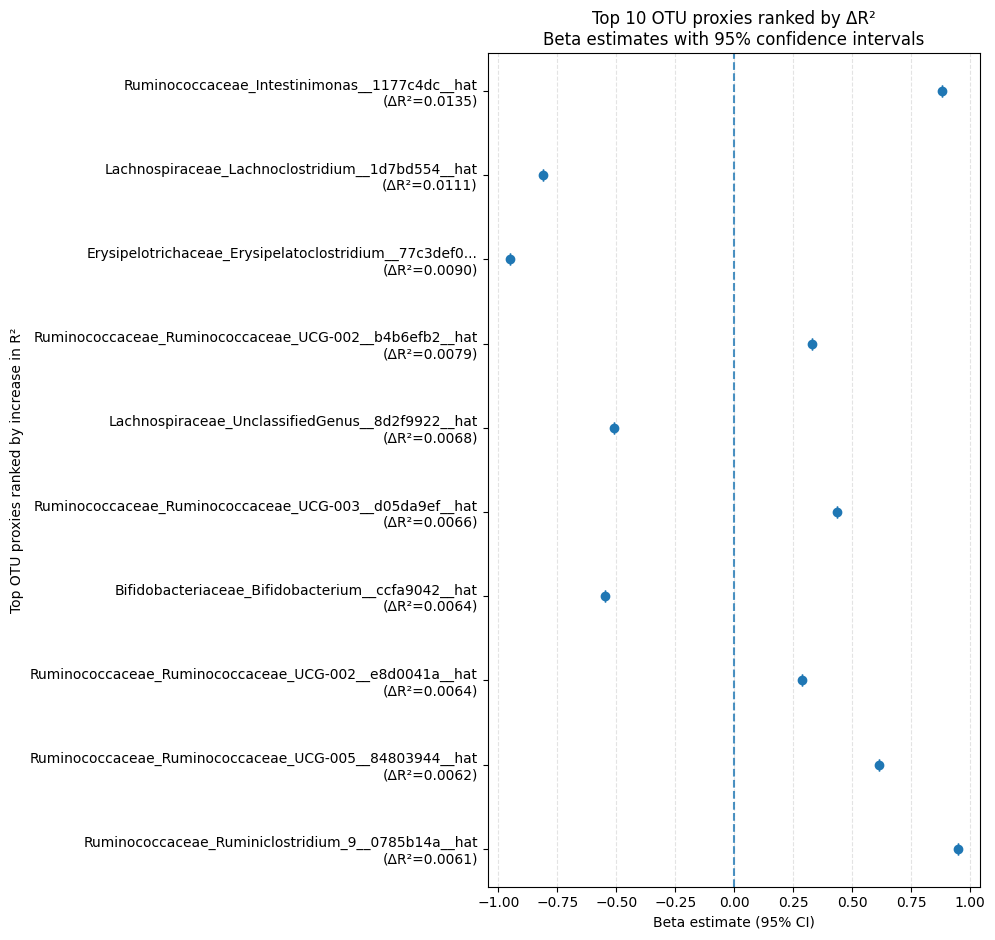

Saved PDF to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/top20_otu_ols_tables/forestplot_top10_ranked_by_delta_r2_beta_95CI.pdf
Saved PNG to: hongrui_result/Ridge_NestedCV_Results/UKB_Ridge_OTU_Projection/top20_otu_ols_tables/forestplot_top10_ranked_by_delta_r2_beta_95CI.png


In [9]:
# ============================================================
# BLOCK 10B
# Classic forest plot using 95% CI
# ============================================================

top_k = 10

if "summary_by_delta_r2" not in globals():
    raise ValueError("summary_by_delta_r2 not found. Please run BLOCK 9 first.")

plot_df = summary_by_delta_r2.head(top_k).copy().iloc[::-1].copy()

def shorten_name(s, max_len=55):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 3] + "..."

plot_df["plot_label"] = [
    f"{shorten_name(row['otu_hat'])}\n(ΔR²={row['delta_r2']:.4f})"
    for _, row in plot_df.iterrows()
]

plot_df["coef"] = pd.to_numeric(plot_df["coef"], errors="coerce")
plot_df["ci_lower"] = pd.to_numeric(plot_df["ci_lower"], errors="coerce")
plot_df["ci_upper"] = pd.to_numeric(plot_df["ci_upper"], errors="coerce")

xerr_left = plot_df["coef"] - plot_df["ci_lower"]
xerr_right = plot_df["ci_upper"] - plot_df["coef"]

ypos = np.arange(len(plot_df))

fig_height = max(6, 0.8 * len(plot_df) + 1.5)
plt.figure(figsize=(10, fig_height))

plt.errorbar(
    x=plot_df["coef"],
    y=ypos,
    xerr=[xerr_left, xerr_right],
    fmt="o",
    capsize=4,
    elinewidth=1.5,
    markersize=6
)

plt.axvline(0, linestyle="--", linewidth=1.5, alpha=0.8)
plt.yticks(ypos, plot_df["plot_label"])
plt.xlabel("Beta estimate (95% CI)")
plt.ylabel("Top OTU proxies ranked by increase in R²")
plt.title("Top 10 OTU proxies ranked by ΔR²\nBeta estimates with 95% confidence intervals")
plt.grid(True, axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()

forest_ci_pdf_path = ols_dir / "forestplot_top10_ranked_by_delta_r2_beta_95CI.pdf"
forest_ci_png_path = ols_dir / "forestplot_top10_ranked_by_delta_r2_beta_95CI.png"

plt.savefig(forest_ci_pdf_path, dpi=300, bbox_inches="tight")
plt.savefig(forest_ci_png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved PDF to: {forest_ci_pdf_path}")
print(f"Saved PNG to: {forest_ci_png_path}")